In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("C:\\Users\\Shahzadi\\Desktop\\ml\\dataset1.csv")
df.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


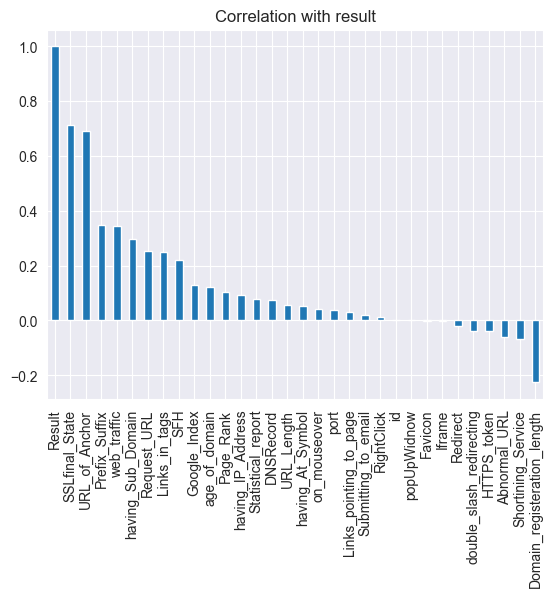

In [5]:
corr = df.corr(numeric_only=True)
corr_target = corr['Result'].sort_values(ascending=False)
corr_target.plot(kind='bar')
plt.title("Correlation with result")
plt.show()

In [7]:
df.drop(columns=['id', 'Abnormal_URL', 'HTTPS_token', 'Favicon', 'Iframe','popUpWidnow', 'Page_Rank','RightClick', 'on_mouseover'], inplace=True,errors='ignore')

In [8]:
X = df.drop('Result', axis=1)
y = df['Result']
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature columns:", X.columns.tolist())

X shape: (11055, 22)
y shape: (11055,)
Feature columns: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'port', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Redirect', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.tree import DecisionTreeClassifier
DC=DecisionTreeClassifier(criterion='entropy', random_state=42,max_depth=5)
DC.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
y_train=DC.predict(x_train)


In [12]:
y_pred = DC.predict(x_test)
print("         MODEL EVALUATION — DC")
print("="*55)
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
print("="*55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"  F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")
print("="*55)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Phishing', 'Legitimate']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

         MODEL EVALUATION — DC
  Accuracy  : 91.72%
  Precision : 88.42%
  Recall    : 97.97%
  F1 Score  : 92.95%

Classification Report:
              precision    recall  f1-score   support

    Phishing       0.97      0.84      0.90       980
  Legitimate       0.88      0.98      0.93      1231

    accuracy                           0.92      2211
   macro avg       0.93      0.91      0.91      2211
weighted avg       0.92      0.92      0.92      2211

Confusion Matrix:
[[ 822  158]
 [  25 1206]]


In [13]:
import re
import joblib
from urllib.parse import urlparse
joblib.dump(DC,'phishing_model.pkl')
print("\nModel saved as phishing_model.pkl")



Model saved as phishing_model.pkl


In [14]:
def extract_features(url):
    parsed = urlparse(url)
    netloc = parsed.netloc
    path   = parsed.path

    features = {
        'having_IP_Address'           : 1 if re.match(r'\d+\.\d+\.\d+\.\d+', netloc) else -1,
        'URL_Length'                  : 1 if len(url) < 54 else (-1 if len(url) > 75 else 0),
        'Shortining_Service'          : -1 if any(s in url for s in ['bit.ly','goo.gl','tinyurl','ow.ly']) else 1,
        'having_At_Symbol'            : -1 if '@' in url else 1,
        'double_slash_redirecting'    : -1 if '//' in path else 1,
        'Prefix_Suffix'               : -1 if '-' in netloc else 1,
        'having_Sub_Domain'           : -1 if netloc.count('.') > 2 else (0 if netloc.count('.') == 2 else 1),
        'SSLfinal_State'              : 1 if parsed.scheme == 'https' else -1,
        'Domain_registeration_length' : 0,
        'port'                        : -1 if ':' in netloc else 1,
        'Request_URL'                 : 1,
        'URL_of_Anchor'               : 0,
        'Links_in_tags'               : 1,
        'SFH'                         : 1,
        'Submitting_to_email'         : -1 if 'mailto:' in url else 1,
        'Redirect'                    : 0,
        'web_traffic'                 : 0,
        'DNSRecord'                   : 0,
        'age_of_domain'               : 0,
        'Google_Index'                : 1,
        'Links_pointing_to_page'      : 0,
        'Statistical_report'          : -1 if any(s in url for s in ['bit.ly','goo.gl']) else 1,
    }
    return features

In [15]:
def predict_url(url):
    features     = extract_features(url)
    feature_cols = x_train.columns.tolist()
    input_data   = pd.DataFrame([features])[feature_cols]
    prediction   = DC.predict(input_data)[0]
    confidence   = DC.predict_proba(input_data).max() * 100
    print("\n" + "="*55)
    print(f"  URL       : {url}")
    print("="*55)
    if confidence < 70:
        # Model is not confident enough — warn the user
        print(f"  RESULT    : SUSPICIOUS — Cannot determine safely")
        print(f"  WARNING   : Low confidence ({confidence:.1f}%) — treat with caution")
    elif prediction == 1:
        print(f"  RESULT    : LEGITIMATE WEBSITE")
        print(f"  CONFIDENCE: {confidence:.1f}%")
    else:
        print(f"  RESULT    : PHISHING / UNSAFE WEBSITE")
        print(f"  CONFIDENCE: {confidence:.1f}%")
    print("="*55)

In [16]:
user_url = input("\nPaste any URL to check: ")
predict_url(user_url)


  URL       : https://www.linkedin.com/mynetwork/grow/
  RESULT    : SUSPICIOUS — Cannot determine safely
